# Cancer Mutation Classification - Modular Analysis


In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

sys.path.append(os.path.abspath('..'))

from src.data_loader import load_clean_data
from src.features import FeatureEngineer
from src.training import train_pipeline
from src.evaluation import evaluate_medical_utility, plot_visual_assessment
from src.config import RANDOM_STATE, TEST_SIZE


I0000 00:00:1776852934.316539    5113 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776852934.317635    5113 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776852934.355723    5113 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776852936.403737    5113 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

## 1. Data Procurement
Loading high-confidence variants (2-4 stars) from the ClinVar summary.

In [2]:
df = load_clean_data(row_limit=1000000)

train_df, test_df = train_test_split(
    df, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE, 
    stratify=df['ClinSigSimple']
)

print(f"Training set: {len(train_df)} variants")
print(f"Test set: {len(test_df)} variants")

Dataset successfully loaded. Final size: 600033 variants.
Training set: 510028 variants
Test set: 90005 variants


## 2. Feature Engineering & Preparation
Extracting biological features (Ti/Tv ratio) and gene-level statistics.

In [3]:
engineer = FeatureEngineer()
X_train = engineer.fit_transform(train_df)
X_test = engineer.transform(test_df)

y_train = train_df['ClinSigSimple'].values
y_test = test_df['ClinSigSimple'].values

## 3. Neural Architecture & Training
The model utilizes a Focal Loss function to maintain high detection rates for rare pathogenic variants.

In [4]:
model, history = train_pipeline(X_train, y_train, engineer)

Epoch 1/100


E0000 00:00:1776807532.227040   20266 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1776807532.227976   20334 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1776807532.239506   20266 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


212/212 ━━━━━━━━━━━━━━━━━━━━ 16s 68ms/step - accuracy: 0.9718 - loss: 0.0114 - precision: 0.6965 - recall: 0.4718 - val_accuracy: 0.9637 - val_loss: 0.0132 - val_precision: 0.9712 - val_recall: 0.0679 - learning_rate: 0.0010
Epoch 2/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 13s 60ms/step - accuracy: 0.9765 - loss: 0.0093 - precision: 0.7735 - recall: 0.5487 - val_accuracy: 0.9732 - val_loss: 0.0098 - val_precision: 0.8763 - val_recall: 0.3621 - learning_rate: 0.0010
Epoch 3/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 13s 60ms/step - accuracy: 0.9770 - loss: 0.0089 - precision: 0.7803 - recall: 0.5582 - val_accuracy: 0.9776 - val_loss: 0.0090 - val_precision: 0.7903 - val_recall: 0.5780 - learning_rate: 0.0010
Epoch 4/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 13s 60ms/step - accuracy: 0.9776 - loss: 0.0086 - precision: 0.7893 - recall: 0.5682 - val_accuracy: 0.9778 - val_loss: 0.0091 - val_precision: 0.8014 - val_recall: 0.5686 - learning_rate: 0.0010
Epoch 5/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 13s 61ms/step - accurac

## 4. Medical Utility Assessment

2813/2813 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step

--- Clinical Performance Appraisal (Threshold: 0.2901) ---
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     86539
           1       0.39      0.85      0.53      3466

    accuracy                           0.94     90005
   macro avg       0.69      0.90      0.75     90005
weighted avg       0.97      0.94      0.95     90005



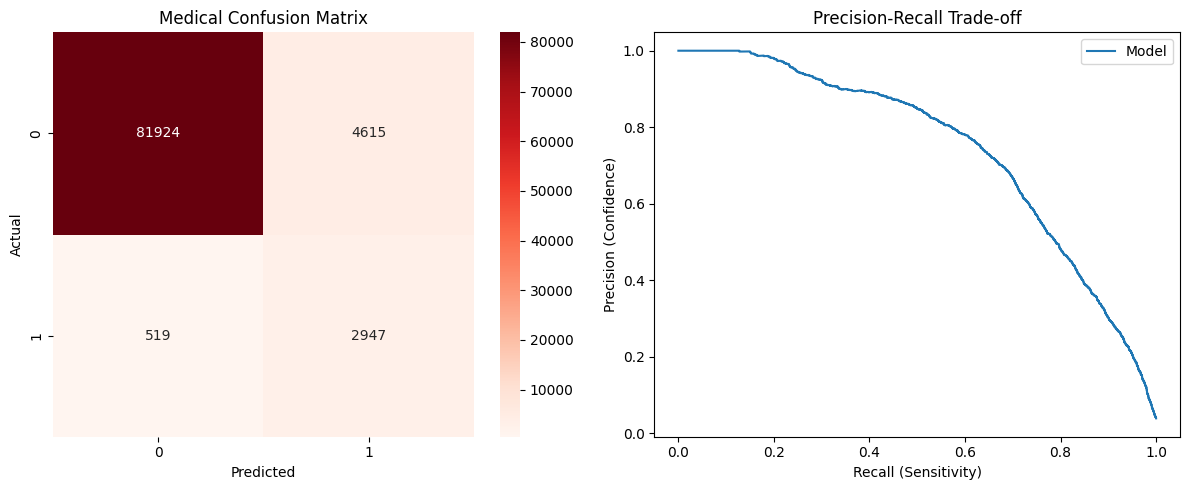

In [5]:
y_pred, y_probs, threshold = evaluate_medical_utility(model, X_test, y_test)
plot_visual_assessment(y_test, y_pred, y_probs)

## 5. Interactive Clinical Inference & Interpretation
This section allows biologists to test the model with individual mutations and receive a human-readable clinical report instead of raw metrics.

In [6]:
from src.evaluation import report_inference

# --- INTERACTIVE TEST AREA ---
# You can change these values to test any mutation.
# The example below is the BRAF V600E mutation (Common in Melanoma).

test_variant = {
    'GeneID': 673,                # Gene ID (e.g., BRAF=673, BRCA1=672)
    'PositionVCF': 140753336,     # Genomic Position (VCF format)
    'ReferenceAlleleVCF': 'A',    # Reference Base
    'AlternateAlleleVCF': 'T',    # Mutant Base
    'Type': 'snp',                # Variant Type (snp, del, ins, etc.)
    'Chromosome': '7'
}

report_inference(model, engineer, test_variant, threshold)


      CANCER MUTATION CLINICAL REPORT
VARIANT: Gene 673 | Pos: 140753336
DNA CHANGE: A -> T
--------------------------------------------------
FINAL CLASSIFICATION: BENIGN (HARMLESS)
CONFIDENCE SCORE: 13.8%
RISK LEVEL: LOW
--------------------------------------------------
BIOLOGICAL CONTEXT:
 - Gene Profile: This gene has a 5.9% historical pathogenicity rate.
 - Mutation Type: snp (Transversion)

CLINICAL ADVICE:
 [ok] Likely a common variation or harmless passenger mutation.
